In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
pd.set_option('display.max_rows', None)

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Global Energy projects/World Energy Consumption.csv")


In [4]:
data.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [5]:
data.columns.to_list()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_cons_change_pct',
 'biofuel_cons_change_twh',
 'biofuel_cons_per_capita',
 'biofuel_consumption',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'biofuel_share_energy',
 'carbon_intensity_elec',
 'coal_cons_change_pct',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_pct',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'coal_share_energy',
 'electricity_demand',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_cons_change_twh',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_energy_per_capita',
 'fossil_fuel_consumption',
 'fossil_share_elec',
 'fossil_share_energy',
 'gas_cons_change_pct',
 'gas_cons_change_twh',
 

In [6]:
data.shape

(22012, 129)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.7+ MB


In [8]:
data["year"].head()

,year
0,2000
1,2001
2,2002
3,2003
4,2004


In [9]:
data['year']=pd.to_datetime(data['year'],format='%Y',errors='coerce')

In [10]:
missing_pct = (data.isna().sum()/len(data)) * 100
missing_pct.sort_values(ascending=False)

,0
biofuel_cons_change_pct,92.063420
solar_cons_change_pct,90.350718
biofuel_cons_per_capita,89.542068
wind_cons_change_pct,89.037798
nuclear_cons_change_pct,88.792477
biofuel_share_energy,87.865710
biofuel_cons_change_twh,87.793022
biofuel_consumption,87.429584
other_renewables_cons_change_pct,83.876976
nuclear_energy_per_capita,82.827549


In [11]:
numeric_cols = data.select_dtypes(include='number').columns
object_cols = data.select_dtypes(include='object').columns

In [12]:
drop_cols = missing_pct[missing_pct > 70].index
data.drop(columns=drop_cols,axis = 1, inplace = True)

In [13]:
important = ['gdp', 'population', 'primary_energy_consumption']

patterns = ['share', 'change', 'per_capita', '_elec_']

cols_to_drop = [col for col in data.columns
                if any(p in col for p in patterns)
                and col not in important]

print(len(cols_to_drop))

26


In [14]:
data.drop(columns=cols_to_drop,axis = 1, inplace = True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   country                      22012 non-null  object        
 1   year                         22012 non-null  datetime64[ns]
 2   iso_code                     16512 non-null  object        
 3   population                   18123 non-null  float64       
 4   gdp                          11113 non-null  float64       
 5   coal_production              16494 non-null  float64       
 6   electricity_generation       7191 non-null   float64       
 7   energy_per_gdp               7211 non-null   float64       
 8   gas_production               16771 non-null  float64       
 9   hydro_electricity            8884 non-null   float64       
 10  low_carbon_electricity       8888 non-null   float64       
 11  nuclear_electricity          8516 non-nul

## Handling Missing Data

In [16]:
rows_null = data[data.isna().sum(axis=1) == 35]
print(len(rows_null))

0


In [17]:
data.drop(rows_null.index,axis = 0, inplace = True)

In [18]:
(data.isna().sum()/len(data)) * 100

,0
country,0.000000
year,0.000000
iso_code,24.986371
population,17.667636
gdp,49.513902
coal_production,25.068145
electricity_generation,67.331456
energy_per_gdp,67.240596
gas_production,23.809740
hydro_electricity,59.640196


In [19]:
iso_map = (data.dropna(subset=['iso_code'])
               .drop_duplicates('country')
               .set_index('country')['iso_code'])

data['iso_code'] = data['iso_code'].fillna(data['country'].map(iso_map))

In [20]:
for col in ['coal_production', 'gas_production', 'oil_production', 'population']:
    data[col] = (data.groupby('country')[col]
                     .transform(lambda x: x.interpolate(
                         method='linear', limit_direction='both')))

In [21]:
mice_cols = ['gdp', 'primary_energy_consumption',
             'coal_production', 'gas_production',
             'oil_production', 'population']

imputed = IterativeImputer(max_iter=10, random_state=42).fit_transform(data[mice_cols])

data[mice_cols] = imputed

In [22]:
mask = data['energy_per_gdp'].isnull()
data.loc[mask, 'energy_per_gdp'] = (
    data.loc[mask, 'primary_energy_consumption'] /
    data.loc[mask, 'gdp'].replace(0, np.nan)
)

data['energy_per_gdp'] = (data.groupby('country')['energy_per_gdp']
                              .transform(lambda x: x.interpolate(
                                  method='linear', limit_direction='both')))

In [23]:

electricity_cols = [
    'electricity_generation', 'hydro_electricity',
    'low_carbon_electricity', 'nuclear_electricity',
    'other_renewable_electricity', 'renewables_electricity',
    'solar_electricity', 'wind_electricity'
]

features = electricity_cols + [
    'gdp', 'population', 'primary_energy_consumption',
    'coal_production', 'gas_production', 'oil_production'
]

mf = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42
)

imputed_elec = mf.fit_transform(data[features])

data[electricity_cols] = imputed_elec[:, :len(electricity_cols)]

In [24]:
for col in data.select_dtypes('float64').columns:
    data[col] = data[col].clip(lower=0)

In [25]:
(data.isna().sum()/len(data))* 100

,0
country,0.000000
year,0.000000
iso_code,24.986371
population,0.000000
gdp,0.000000
coal_production,0.000000
electricity_generation,0.000000
energy_per_gdp,0.000000
gas_production,0.000000
hydro_electricity,0.000000


In [26]:
data['iso_code'].nunique()

219

In [27]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

known_mask = data['iso_code'].notna()
le.fit(data.loc[known_mask, 'iso_code'])

data['iso_code_encoded'] = np.nan
data.loc[known_mask, 'iso_code_encoded'] = le.transform(
    data.loc[known_mask, 'iso_code']
)

print(f"iso_code_encoded nulls: {data['iso_code_encoded'].isnull().sum()}")

iso_code_encoded nulls: 5500


In [28]:

features_for_iso = [
    'iso_code_encoded',
    'gdp', 'population', 'primary_energy_consumption',
    'coal_production', 'gas_production', 'oil_production'
]

mf_iso = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42
)

imputed_iso = mf_iso.fit_transform(data[features_for_iso])

data['iso_code_encoded'] = np.round(imputed_iso[:, 0]).astype(int)

max_class = len(le.classes_) - 1
data['iso_code_encoded'] = data['iso_code_encoded'].clip(0, max_class)

print(f"iso_code_encoded nulls after: {data['iso_code_encoded'].isnull().sum()}")

iso_code_encoded nulls after: 0


In [29]:

data['iso_code'] = le.inverse_transform(data['iso_code_encoded'])

data.drop(columns=['iso_code_encoded'], inplace=True)

print(f"iso_code nulls final: {data['iso_code'].isnull().sum()}")
print(data['iso_code'].value_counts().head(10))

iso_code nulls final: 0
iso_code
UKR    462
TLS    428
GUF    361
GAB    276
LVA    267
RUS    235
PER    222
USA    205
SYR    193
EGY    189
Name: count, dtype: int64


In [30]:
data.isna().sum()

,0
country,0
year,0
iso_code,0
population,0
gdp,0
coal_production,0
electricity_generation,0
energy_per_gdp,0
gas_production,0
hydro_electricity,0


### Duplicate

In [31]:
data.duplicated().sum()

np.int64(0)

In [32]:
data.head()

,country,year,iso_code,population,gdp,coal_production,electricity_generation,energy_per_gdp,gas_production,hydro_electricity,low_carbon_electricity,nuclear_electricity,oil_production,other_renewable_electricity,primary_energy_consumption,renewables_electricity,solar_electricity,wind_electricity
0,ASEAN (Ember),2000-01-01,GUF,1.050371e+08,9.869936e+11,1022.131161,368.65,3.620245e-09,632.343592,50.37,72.90,0.0,1018.874757,22.53,3573.158459,72.90,0.0,0.0
1,ASEAN (Ember),2001-01-01,GUF,1.050371e+08,9.869936e+11,1022.131161,397.19,3.620245e-09,632.343592,54.26,76.68,0.0,1018.874757,22.42,3573.158459,76.68,0.0,0.0
2,ASEAN (Ember),2002-01-01,GUF,1.050371e+08,9.869936e+11,1022.131161,422.82,3.620245e-09,632.343592,53.32,75.99,0.0,1018.874757,22.67,3573.158459,75.99,0.0,0.0
3,ASEAN (Ember),2003-01-01,GUF,1.050371e+08,9.869936e+11,1022.131161,447.15,3.620245e-09,632.343592,53.28,75.71,0.0,1018.874757,22.43,3573.158459,75.71,0.0,0.0
4,ASEAN (Ember),2004-01-01,GUF,1.050371e+08,9.869936e+11,1022.131161,484.94,3.620245e-09,632.343592,52.88,77.02,0.0,1018.874757,24.14,3573.158459,77.02,0.0,0.0


## outlier

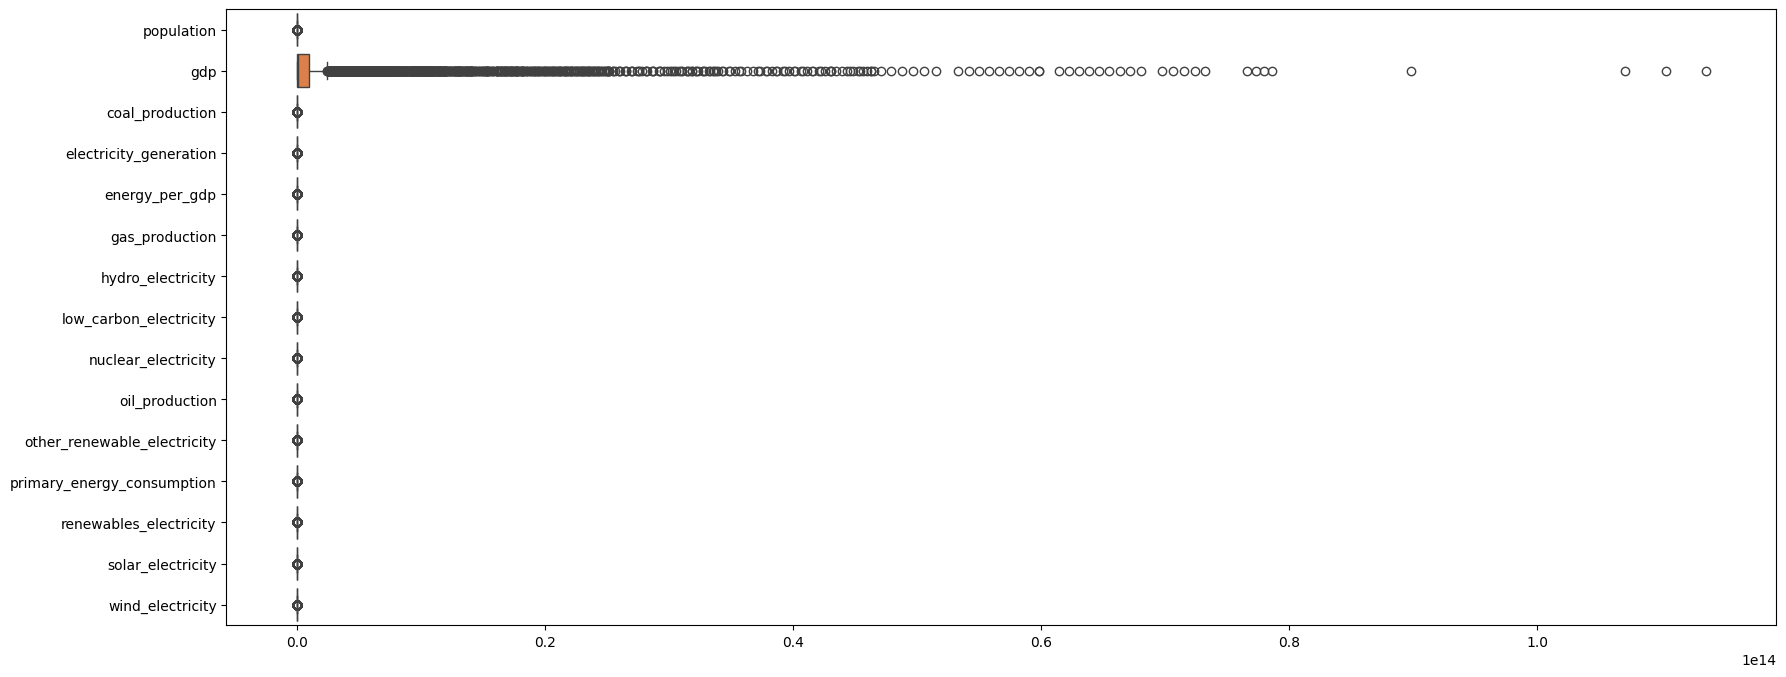

In [58]:
plt.figure(figsize = (20, 8))
sns.boxplot(data = data, orient='h')
plt.show()

### data is important and found outlier is natural so we can't remove this outlier but we can handle it using log and simple Capping

In [60]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

data[num_cols] =  np.log1p(data[num_cols])

In [61]:
for col in num_cols:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data[col] = np.clip(data[col], lower, upper)

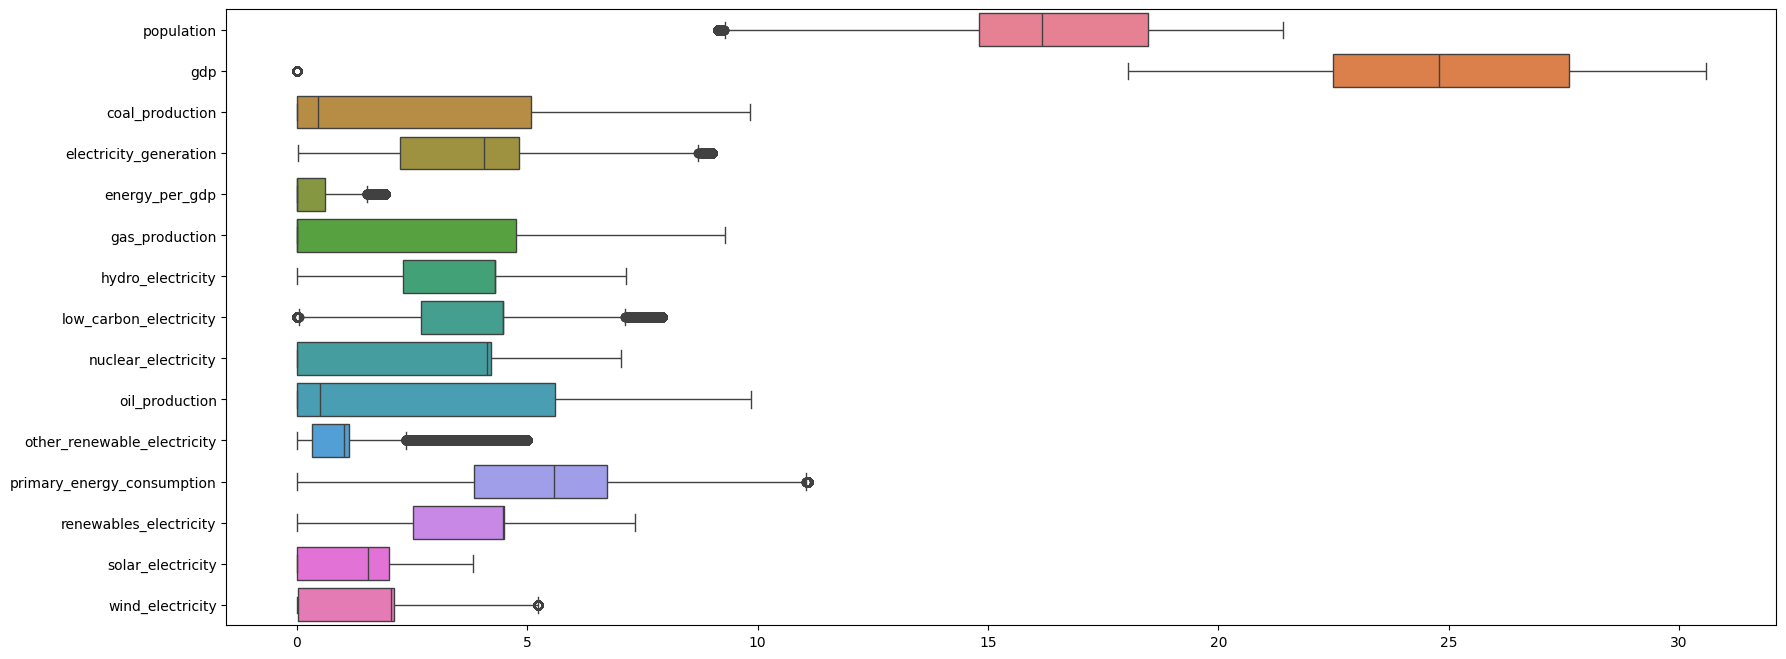

In [62]:
plt.figure(figsize = (20, 8))
sns.boxplot(data = data, orient='h')
plt.show()

In [64]:
skew_df = data[num_cols].skew().sort_values(ascending=False).reset_index()
skew_df.columns = ['Feature', 'Skewness']

/tmp/ipykernel_1386/3058222835.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(skew_df, shade=True)


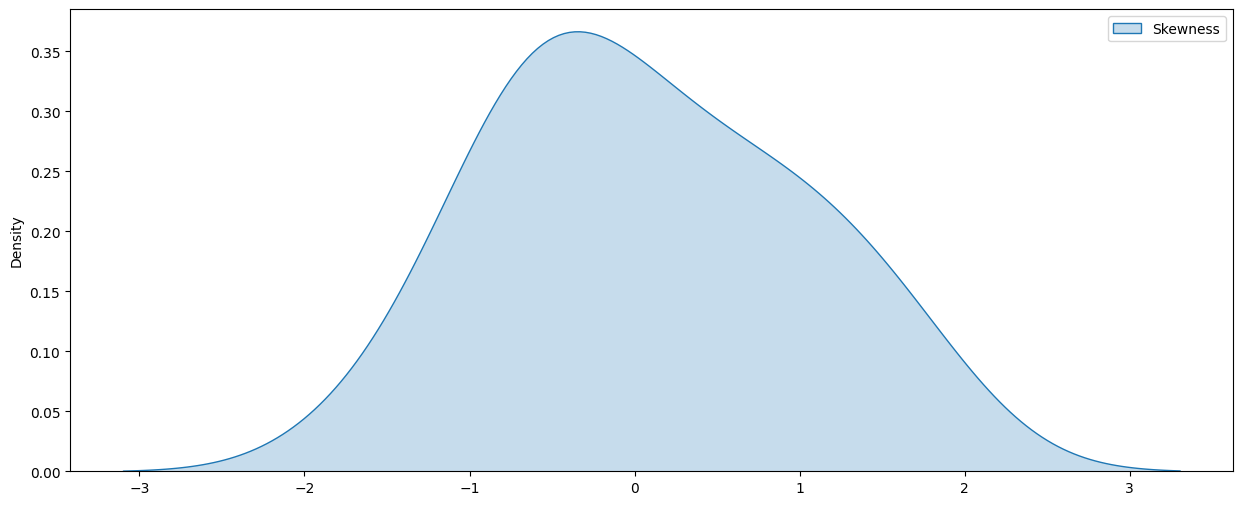

In [69]:
plt.figure(figsize = (15, 6))
sns.kdeplot(skew_df, shade=True)
plt.show()

In [73]:
data.to_csv("cleaned_data.csv", index = False)

In [77]:
x = pd.read_csv("/content/cleaned_data.csv")

In [78]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      22012 non-null  object 
 1   year                         22012 non-null  object 
 2   iso_code                     22012 non-null  object 
 3   population                   22012 non-null  float64
 4   gdp                          22012 non-null  float64
 5   coal_production              22012 non-null  float64
 6   electricity_generation       22012 non-null  float64
 7   energy_per_gdp               22012 non-null  float64
 8   gas_production               22012 non-null  float64
 9   hydro_electricity            22012 non-null  float64
 10  low_carbon_electricity       22012 non-null  float64
 11  nuclear_electricity          22012 non-null  float64
 12  oil_production               22012 non-null  float64
 13  other_renewable_